# Week 5: Unsupervised Learning - PCA Live Session

**Welcome!** In this notebook, you'll follow along with the instructor to use PCA for dimensionality reduction and visualization.

**Dataset:** MNIST Digits (sklearn version)  
**Goal:** Compress 64 dimensions to 2D for visualization while preserving digit patterns

---

## What You'll Learn Today

By the end of this session, you'll be able to:
1. ✅ Build a complete PCA pipeline
2. ✅ Understand explained variance ratio
3. ✅ Create and interpret scree plots
4. ✅ Reduce high-dimensional data to 2D
5. ✅ Visualize MNIST digits in 2D space
6. ✅ Understand the dimensionality reduction vs information loss tradeoff

---

## 📝 How to Use This Notebook

**Scaffolding Level:** 50% provided (midpoint independence)

**Your task:**
1. 👂 **Listen** to the instructor explain each concept
2. 🔨 **Fill in** the TODO sections (hints provided)
3. ▶️ **Run** the cell and verify output
4. 👀 **Observe** the stunning visualization!
5. ❓ **Ask questions** if anything is unclear

**Remember:** PCA finds the directions of maximum variance!

---

Let's begin!

---

## Step 1: Setup & Imports

**What we're doing:** Importing all the tools we need for PCA

**Listen to the instructor explain each import, then run this cell:**

In [87]:
# Week 5: PCA Dimensionality Reduction
# MNIST Digits Dataset

# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load MNIST digits
from sklearn.datasets import load_digits

# Preprocessing
from sklearn.preprocessing import StandardScaler

# PCA (NEW!)
from sklearn.decomposition import PCA

# Visualization settings
%matplotlib inline
sns.set_style('whitegrid')

print("✅ All imports successful!")

✅ All imports successful!


**Expected Output:** `✅ All imports successful!`

---

### 💡 New Import:
- `PCA` - Our dimensionality reduction algorithm
- `load_digits` - MNIST handwritten digits dataset

---

## Step 2: Load and Explore MNIST Digits

**What we're doing:** Loading handwritten digit images and understanding the high dimensionality

**Dataset context:**
- 1,797 images of handwritten digits (0-9)
- Each image is 8×8 pixels = **64 features**
- Challenge: How do we visualize 64-dimensional data?

**Listen to the instructor, then run this cell:**

In [88]:
# Load MNIST digits
print("Loading MNIST digits dataset...")
digits = load_digits()

X = digits.data      # Features (pixel values)
y = digits.target    # True labels (0-9)

print(f"✅ Data loaded successfully!")
print(f"\nDataset Information:")
print(f"  X shape: {X.shape}")  # (1797, 64) - each image is 8x8 = 64 pixels
print(f"  y shape: {y.shape}")  # (1797,)
print(f"  Classes: {np.unique(y)}")
print(f"\nChallenge: 64 dimensions - can't plot this directly!")

Loading MNIST digits dataset...
✅ Data loaded successfully!

Dataset Information:
  X shape: (1797, 64)
  y shape: (1797,)
  Classes: [0 1 2 3 4 5 6 7 8 9]

Challenge: 64 dimensions - can't plot this directly!


**Expected output:** X shape: (1797, 64)

**The challenge:**
- Each image is 64 dimensions (8×8 pixels)
- We can only visualize 2D or 3D
- PCA will compress 64D → 2D!

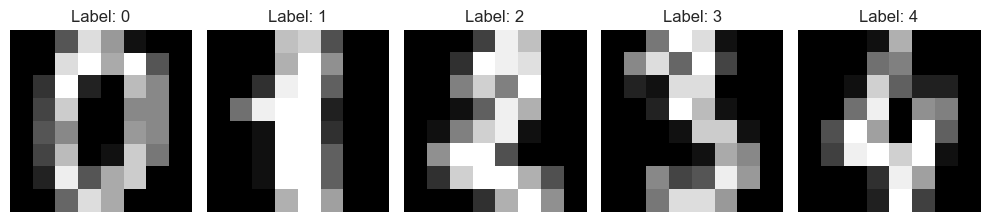

Each digit is 8×8 pixels = 64 pixel values = 64 features!


In [89]:
# Visualize some sample digits
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X[i].reshape(8, 8), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

print("Each digit is 8×8 pixels = 64 pixel values = 64 features!")

---

## Step 3: Feature Scaling

**Before PCA, scale features!** PCA is distance-based, so similar scales are critical.

**Your first TODO!** Scale the features.

**Listen to the instructor, then complete and run:**

In [90]:
# Check original pixel value range
print("Original pixel values:")
print(f"  Min: {X.min()}")
print(f"  Max: {X.max()}")
print(f"  Mean: {X.mean():.2f}")

Original pixel values:
  Min: 0.0
  Max: 16.0
  Mean: 4.88


In [91]:
# TODO: Scale features using StandardScaler
# Hint: Create scaler, then fit_transform()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features scaled!")
print(f"\nAfter scaling:")
print(f"  Mean: {X_scaled.mean():.2f}")  # Should be ~0
print(f"  Std:  {X_scaled.std():.2f}")   # Should be ~1

✅ Features scaled!

After scaling:
  Mean: 0.00
  Std:  0.98


**Expected output:** Mean ≈ 0.00, Std ≈ 1.00

**Critical:** Always scale before PCA!

---

## Step 4: Fit PCA - Analyze Variance Explained ⭐ **CRITICAL**

**First, let's fit PCA with ALL components to understand variance distribution.**

**Your second TODO!** Fit PCA and analyze variance.

**Listen to the instructor, then complete and run:**

In [92]:
# TODO: Fit PCA with all components
# Hint: PCA() with no n_components keeps all

pca_full = PCA()  # No n_components = keep all
pca_full.fit(X_scaled)

# Get explained variance ratio
var_ratio = pca_full.explained_variance_ratio_

print(f"✅ PCA fitted!")
print(f"Number of components: {len(var_ratio)}")
print(f"\nVariance explained by first 5 components:")
for i in range(5):
    print(f"  PC{i+1}: {var_ratio[i]:.4f} ({var_ratio[i]*100:.2f}%)")

✅ PCA fitted!
Number of components: 64

Variance explained by first 5 components:
  PC1: 0.1203 (12.03%)
  PC2: 0.0956 (9.56%)
  PC3: 0.0844 (8.44%)
  PC4: 0.0650 (6.50%)
  PC5: 0.0486 (4.86%)


**What is explained variance ratio?**
- Each principal component explains some % of total variance
- PC1 explains the most (usually 10-15%)
- PC2 explains second most, and so on
- All components sum to 100%

**Example:** PC1 = 12% means "First component captures 12% of total information"

In [93]:
# TODO: Calculate cumulative variance
# Hint: Use np.cumsum() on var_ratio

cum_var = np.cumsum(var_ratio)

print("Cumulative variance explained:")
print(f"  First 2 components:  {cum_var[1]:.4f} ({cum_var[1]*100:.1f}%)")
print(f"  First 5 components:  {cum_var[4]:.4f} ({cum_var[4]*100:.1f}%)")
print(f"  First 10 components: {cum_var[9]:.4f} ({cum_var[9]*100:.1f}%)")
print(f"  First 20 components: {cum_var[19]:.4f} ({cum_var[19]*100:.1f}%)")

Cumulative variance explained:
  First 2 components:  0.2159 (21.6%)
  First 5 components:  0.4140 (41.4%)
  First 10 components: 0.5887 (58.9%)
  First 20 components: 0.7931 (79.3%)


**Cumulative variance shows:**
- First 2 components: ~20-25% of variance
- First 10 components: ~60-70% of variance
- First 20 components: ~85-90% of variance

**Tradeoff:** Fewer components = easier to visualize, but more information lost!

---

## Step 5: Create Scree Plot

**Scree plot:** Visualizes variance explained by each component

**Your third TODO!** Create the scree plot.

**Listen to the instructor, then complete and run:**

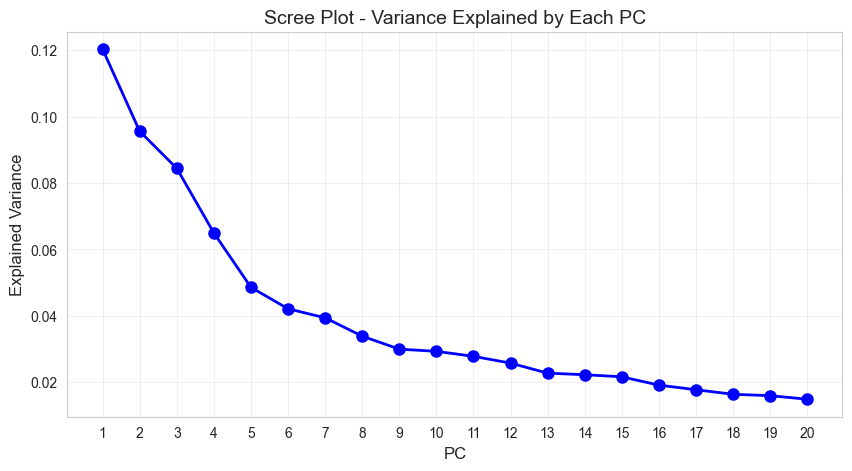

In [94]:
# TODO: Create scree plot
# Hint: Plot component number vs variance explained

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), var_ratio[:20], 'bo-', linewidth=2, markersize=8)
plt.xlabel('PC', fontsize=12)  # Principal Component
plt.ylabel('Explained Variance', fontsize=12)  # Variance Explained
plt.title('Scree Plot - Variance Explained by Each PC', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))
plt.show()

**Interpreting the scree plot:**
- PC1 has highest variance explained
- Drops quickly for PC2, PC3, etc.
- After PC10-15, curve flattens (diminishing returns)
- Look for "elbow" to choose number of components

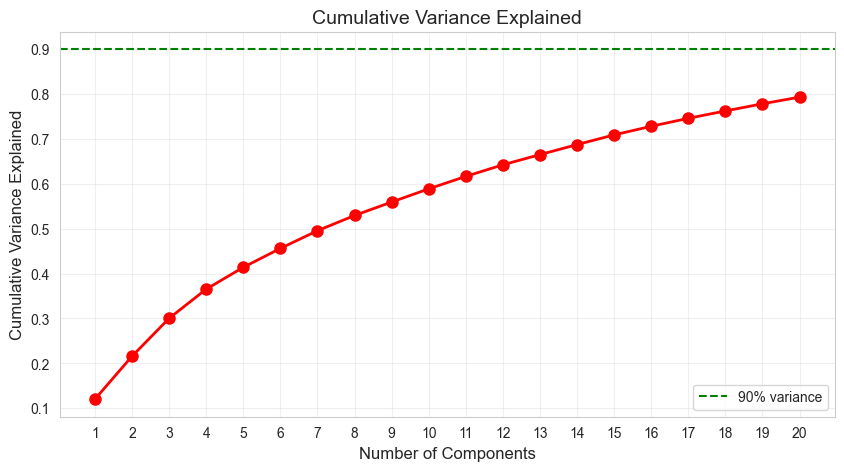

To retain 90% variance, need ~31 components


In [95]:
# Optional: Cumulative variance plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), cum_var[:20], 'ro-', linewidth=2, markersize=8)
plt.axhline(y=0.90, color='green', linestyle='--', label='90% variance')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance Explained', fontsize=12)
plt.title('Cumulative Variance Explained', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))
plt.show()

print(f"To retain 90% variance, need ~{np.argmax(cum_var >= 0.90) + 1} components")

---

## Step 6: Reduce to 2D ⭐ **THE COMPRESSION!**

**Now let's compress 64 dimensions to just 2 for visualization!**

**Your fourth TODO!** Fit PCA with 2 components.

**Listen to the instructor, then complete and run:**

In [96]:
# TODO: Create PCA with 2 components
# Hint: PCA(n_components=2, random_state=42)

pca_2d = PCA(n_components=2, random_state=42)

# TODO: Fit and transform the data
# Hint: Use fit_transform()
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"✅ Dimensionality reduction complete!")
print(f"\nOriginal shape: {X_scaled.shape}")  # (1797, 64)
print(f"After PCA: {X_pca_2d.shape}")  # (1797, 2)
print(f"\nVariance explained by 2 components: {pca_2d.explained_variance_ratio_.sum():.4f}")
print(f"Variance lost: {1 - pca_2d.explained_variance_ratio_.sum():.4f}")

✅ Dimensionality reduction complete!

Original shape: (1797, 64)
After PCA: (1797, 2)

Variance explained by 2 components: 0.2159
Variance lost: 0.7841


**Expected output:**
- Original: (1797, 64)
- After PCA: (1797, 2)
- Variance explained: ~20-25%
- Variance lost: ~75-80%

**The tradeoff:**
- We compressed 64D → 2D (massive compression!)
- We kept only ~25% of information
- But now we can VISUALIZE it!

---

## Step 7: Visualize MNIST in 2D ⭐ **THE PAYOFF!**

**This is the stunning moment - 64D data visualized in 2D!**

**Your fifth TODO!** Create the 2D scatter plot.

**Listen to the instructor, then complete and run:**

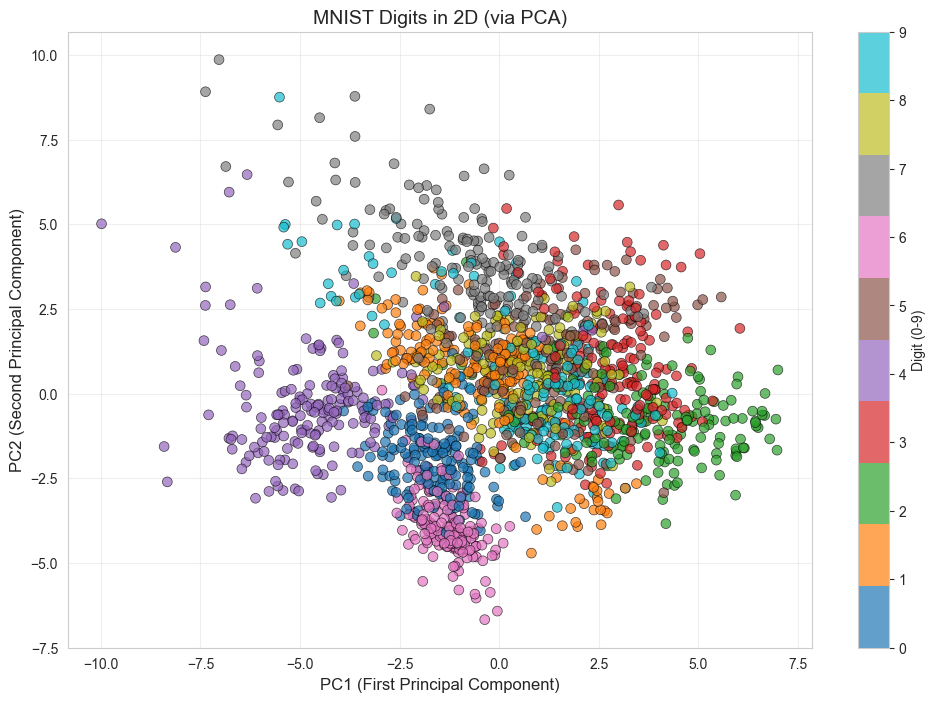

In [97]:
# TODO: Create 2D visualization
# Hint: plt.scatter(x, y, c=labels, cmap='tab10')
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_pca_2d[:, 0],  # PC1
    X_pca_2d[:, 1],  # PC2
    c=y,  # Color by true digit class
    cmap='tab10',
    s=50,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)

plt.xlabel('PC1 (First Principal Component)', fontsize=12)
plt.ylabel('PC2 (Second Principal Component)', fontsize=12)
plt.title('MNIST Digits in 2D (via PCA)', fontsize=14)
plt.colorbar(scatter, label='Digit (0-9)', ticks=range(10))
plt.grid(True, alpha=0.3)
plt.show()

**WOW!** Look at this visualization!

**What to observe:**
- Different digits form distinct regions/clusters
- Some digits separate well (0, 1, 6, 4)
- Some overlap (3, 5, 8) - visually similar digits
- We lost 75% of variance, but patterns are preserved!

**This is the magic of PCA:**
- 64 dimensions compressed to 2
- Still see digit structure
- Enables exploratory data analysis

---

## 🎉 Congratulations!

You've just used PCA to visualize high-dimensional data!

**What you accomplished:**
1. ✅ Loaded MNIST digits (64 dimensions)
2. ✅ Scaled features (CRITICAL for PCA)
3. ✅ Analyzed variance explained
4. ✅ Created scree plot
5. ✅ Compressed 64D → 2D
6. ✅ Visualized digits in 2D space
7. ✅ Understood dimensionality reduction tradeoff

---

## 💡 Key Takeaways

**Remember these critical concepts:**

1. **PCA enables visualization:**
   - Can't plot 64D directly
   - PCA reduces to 2D or 3D
   - Preserves most important patterns

2. **Variance explained tells information retained:**
   - Each PC explains % of variance
   - 2 PCs kept ~25% of information
   - Lost 75%, but visualization is worth it!

3. **Scree plot helps choose components:**
   - Shows variance drop-off
   - Look for "elbow"
   - For visualization: 2-3 components
   - For preprocessing: retain 85-95% variance

4. **Always scale before PCA:**
   - PCA is distance-based
   - Use StandardScaler!

5. **PCA has multiple uses:**
   - Visualization (today's focus)
   - Preprocessing for supervised learning
   - Noise reduction
   - Data compression

---

## 🚀 Next Steps

**Now: Pair programming!**
- "Cluster Detective" exercise
- Practice cluster interpretation on Wine dataset
- Apply K-Means skills learned today

**Tonight's homework:**
- Wine dataset clustering (40% scaffolding)
- Combine K-Means + PCA for visualization
- Practice interpretation

**Bonus challenge:**
- PCA + supervised learning
- Use PCA for preprocessing before classification

---

## ❓ Reflection Questions

**Take a moment to think about:**

1. What does "explained variance" mean in simple terms?

2. Why did we lose 75% of variance but still see digit patterns?

3. When would you use PCA in practice?

4. How is PCA different from K-Means?

5. Could you use PCA before classification? Why or why not?

---

**Excellent work! Ready for pair programming?** 🎓

---

*Week 5 PCA Live Session v1.0 | February 2026*